# Principal component as a Grassmann point

Principal component analysis estimates a subspace rather than a particular
basis. The Grassmann manifold captures exactly this invariance: a matrix $X$
and $XR$, with $R$ orthogonal, represent the same subspace.

For a covariance matrix $C$, the leading $k$-dimensional principal subspace
solves

$$
\min_{[X]\in\operatorname{Gr}(k,n)}
-\operatorname{tr}(X^\top C X),
\qquad X^\top X=I_k.
$$

Here we use $\operatorname{Gr}(1,3)$ so the estimated one-dimensional subspace
can be plotted through a three-dimensional cloud.

In [1]:
import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
import matplotlib.pyplot as plt

from geojax.geometry import Grassmann, GrassmannProjection
from geojax.optimization import ConjugateGradient, Minimize

key = jax.random.key(12)
angle = 0.65
rotation = jnp.array([
    [jnp.cos(angle), -jnp.sin(angle), 0.0],
    [jnp.sin(angle),  jnp.cos(angle), 0.0],
    [0.0, 0.0, 1.0],
])
transform = rotation @ jnp.diag(jnp.array([2.4, 0.75, 0.28]))
data = jax.random.normal(key, shape=(240, 3)) @ transform.T
covariance = data.T @ data / data.shape[0]

M = Grassmann(size=(3, 1))
x0 = M.random_point(jax.random.key(3))

def cost(X):
    return -jnp.trace(X.T @ covariance @ X)

In [2]:
problem = Minimize(
    M=M,
    cost=cost,
    x0=x0,
    solver=ConjugateGradient(maxiter=100, tolgradnorm=1e-9, verbosity=0),
)
X_hat, final_cost, history = problem.solve()

eigenvalues, eigenvectors = jnp.linalg.eigh(covariance)
principal = eigenvectors[:, -1]
estimate = X_hat[:, 0]
if jnp.dot(estimate, principal) < 0:
    estimate = -estimate

principal_angle = M.dist(estimate[:, None], principal[:, None])
explained = eigenvalues[-1] / jnp.sum(eigenvalues)
print(f"principal angle error : {float(principal_angle):.3e} radians")
print(f"variance explained    : {float(explained):.3%}")
print(f"iterations            : {history[-1].iter}")

principal angle error : 2.940e-08 radians
variance explained    : 89.226%
iterations            : 41


## The same estimate as a projector

Both Grassmann geometries accept orthonormal frames as public points. The
projection geometry maps those frames to basis-independent matrices internally.
For this rank-one problem, the embedded estimated and reference projectors are

$$
P_{\mathrm{estimate}}=\hat{x}\hat{x}^\top,
\qquad
P_{\mathrm{reference}}=x_\star x_\star^\top.
$$

The intrinsic distance measures the principal angle. The chordal distance
measures the straight Frobenius chord between these two matrices.

In [3]:
MP = GrassmannProjection(size=(3, 1))
P_estimate = MP.embed(estimate[:, None])
P_reference = MP.embed(principal[:, None])

print(f"public point shape: {MP.shape}")
print(f"embedded shape    : {P_estimate.shape}")
print(f"geodesic distance : {float(MP.dist(estimate[:, None], principal[:, None])):.3e}")
print(f"chordal distance  : {float(MP.chordal_dist(estimate[:, None], principal[:, None])):.3e}")

public point shape: (3, 1)
embedded shape    : (3, 3)
geodesic distance : 2.940e-08
chordal distance  : 2.940e-08


chordal distance  : 2.940e-08


The projector also makes basis invariance visible: reversing the sign of the
eigenvector leaves every matrix entry unchanged.

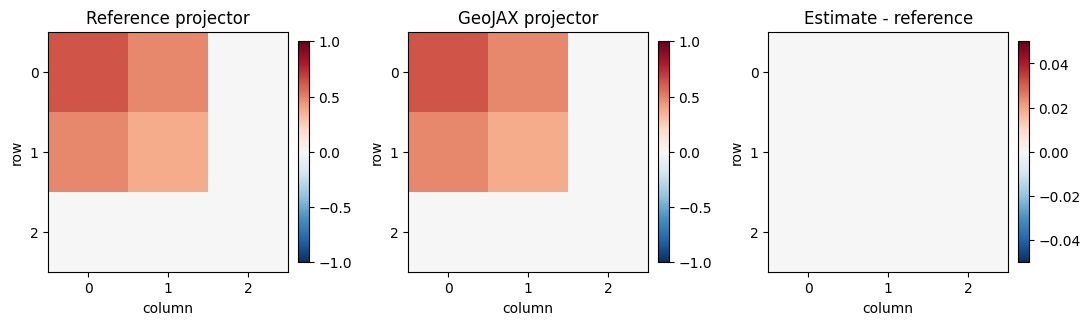

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(10.8, 3.25), constrained_layout=True)
matrices = [P_reference, P_estimate, P_estimate - P_reference]
titles = ["Reference projector", "GeoJAX projector", "Estimate - reference"]
limits = [(-1.0, 1.0), (-1.0, 1.0), (-0.05, 0.05)]

for ax, matrix, title, (vmin, vmax) in zip(axes, matrices, titles, limits):
    image = ax.imshow(matrix, cmap="RdBu_r", vmin=vmin, vmax=vmax)
    ax.set(title=title, xlabel="column", ylabel="row", xticks=range(3), yticks=range(3))
    fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)

plt.show()

## Subspace and convergence

The line is drawn in both directions because a Grassmann point does not choose
an orientation. The direct eigensolver and GeoJAX estimate visually overlap.

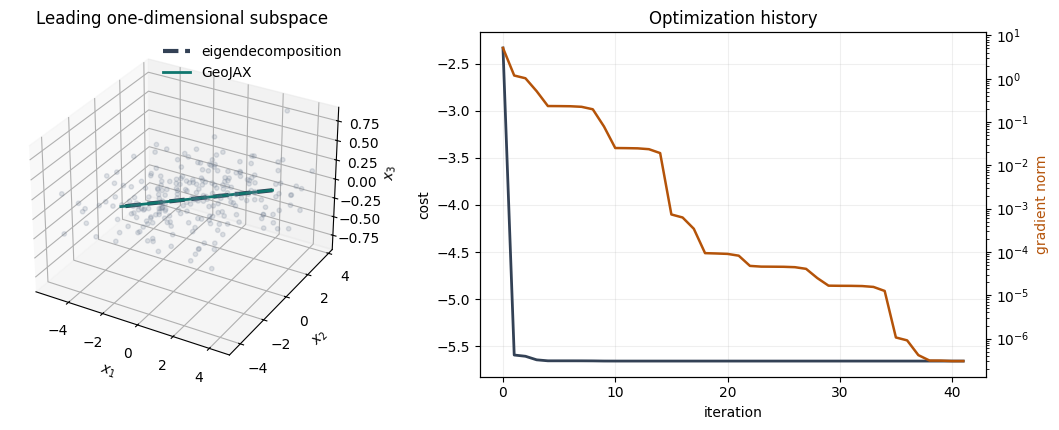

In [5]:
fig = plt.figure(figsize=(11.5, 4.4))
ax = fig.add_subplot(1, 2, 1, projection="3d")
ax.scatter(data[:, 0], data[:, 1], data[:, 2], s=10, alpha=0.18, color="#64748b")

extent = 3.6
line = jnp.linspace(-extent, extent, 2)
ax.plot(*(line[:, None] * principal[None, :]).T, color="#334155", linestyle="--",
        linewidth=3, label="eigendecomposition")
ax.plot(*(line[:, None] * estimate[None, :]).T, color="#0f766e", linewidth=2,
        label="GeoJAX")
ax.set(title="Leading one-dimensional subspace", xlabel="$x_1$", ylabel="$x_2$", zlabel="$x_3$")
ax.set_box_aspect((1, 1, 0.75))
ax.legend(frameon=False)

ax = fig.add_subplot(1, 2, 2)
costs = jnp.array([row.cost for row in history])
gradnorm = jnp.array([max(row.gradnorm, 1e-16) for row in history])
ax.plot(costs, color="#334155", linewidth=2, label="cost")
ax.set(title="Optimization history", xlabel="iteration", ylabel="cost")
ax2 = ax.twinx()
ax2.semilogy(gradnorm, color="#b45309", linewidth=1.8, label="gradient norm")
ax2.set_ylabel("gradient norm", color="#b45309")
ax.grid(alpha=0.2)

fig.tight_layout()
plt.show()

The same formulation extends directly to `Grassmann(size=(n, k))` for a
$k$-dimensional principal subspace; only the number of columns in the point
representation changes.